# 03 — Modelado No Supervisado

**Objetivo:** Descubrir perfiles latentes de empleados sin usar etiquetas,  
usando K-Means, DBSCAN, Clustering Jerárquico, PCA y GMM.

**Estrategia de análisis:**
- K-Means como algoritmo principal: eficiente, interpretable, métricas de selección de K
- DBSCAN para detectar outliers y clusters de densidad variable
- PCA para reducción y visualización en 2D/3D
- GMM para modelar clusters con distribuciones elípticas
- Interpretación de negocio: ¿qué perfil de empleado representa cada cluster?

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
os.chdir(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

from ev_parcial2_gonzalez.modeling.train import load_data
from ev_parcial2_gonzalez.modeling.unsupervised import (
    prepare_unsupervised_data, run_kmeans, run_dbscan,
    run_agglomerative, run_pca, run_gmm, interpret_clusters
)
from ev_parcial2_gonzalez.modeling.unsupervised_visualization import (
    plot_elbow_silhouette, plot_dendrogram, plot_pca_2d,
    plot_pca_3d, plot_silhouette, plot_cluster_heatmap, plot_gmm_aic_bic
)
from ev_parcial2_gonzalez.modeling.config import NUMERIC_FEATURES

df = load_data()
X_scaled = prepare_unsupervised_data(df)
print(f"Datos escalados: {X_scaled.shape}  (filas × features numéricas)")

2026-05-22 19:31:03 | ev_parcial2_gonzalez.modeling.train | INFO     | Dataset cargado: (3000, 33)
2026-05-22 19:31:03 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | ▶ Iniciando: prepare_unsupervised_data
2026-05-22 19:31:03 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | Datos no supervisados: (3000, 6)
2026-05-22 19:31:03 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | ✔ Completado: prepare_unsupervised_data (0.00s)


Datos escalados: (3000, 6)  (filas × features numéricas)


## 1. K-Means: Selección del K Óptimo

Se evalúan k=2 a k=8 con dos métricas complementarias:
- **Silhouette Score** (↑ mejor): mide qué tan similar es un punto a su propio cluster vs otros
- **Davies-Bouldin Index** (↓ mejor): ratio de dispersión intra-cluster vs distancia inter-cluster

2026-05-22 19:31:04 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | ▶ Iniciando: run_kmeans
2026-05-22 19:31:04 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | K=2 | Inertia=15679.24 | Sil=0.1292 | DB=2.5364
2026-05-22 19:31:04 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | K=3 | Inertia=14234.05 | Sil=0.1266 | DB=2.2604
2026-05-22 19:31:04 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | K=4 | Inertia=13106.96 | Sil=0.1253 | DB=1.9813
2026-05-22 19:31:05 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | K=5 | Inertia=12205.66 | Sil=0.1264 | DB=1.8392
2026-05-22 19:31:05 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | K=6 | Inertia=11374.87 | Sil=0.1273 | DB=1.7314
2026-05-22 19:31:05 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | K=7 | Inertia=10715.76 | Sil=0.1310 | DB=1.6058
2026-05-22 19:31:05 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | K=8 | Inertia=10224.99 | Sil=0.1312 | DB=1.6332
2026-05-22 19:31

,K,Inertia,Silhouette
0,2,"15,679.24",0.1292
1,3,"14,234.05",0.1266
2,4,"13,106.96",0.1253
3,5,"12,205.66",0.1264
4,6,"11,374.87",0.1273
5,7,"10,715.76",0.1310
6,8,"10,224.99",0.1312


2026-05-22 19:31:05 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ▶ Iniciando: plot_elbow_silhouette
2026-05-22 19:31:05 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ✔ Completado: plot_elbow_silhouette (0.08s)


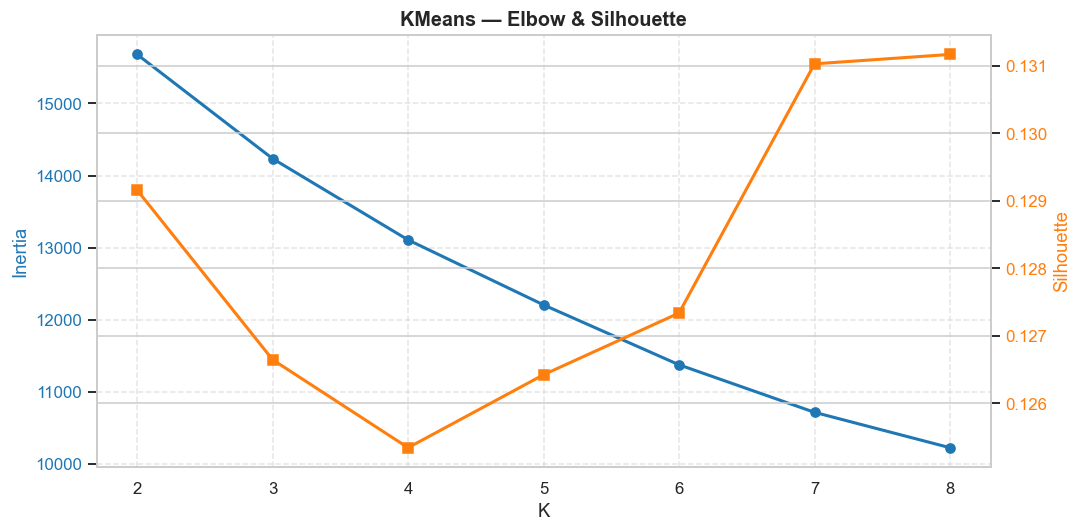

In [3]:
km = run_kmeans(X_scaled)

# Tabla de métricas
metricas_km = pd.DataFrame({
    "K": km["k_values"],
    "Inertia": [f"{v:,.2f}" for v in km["inertias"]],
    "Silhouette": [f"{v:.4f}" for v in km["silhouettes"]],
})
if "davies_bouldins" in km:
    metricas_km["Davies-Bouldin"] = [f"{v:.4f}" for v in km["davies_bouldins"]]
display(metricas_km)

plot_elbow_silhouette(km["k_values"], km["inertias"], km["silhouettes"])
plt.savefig("results/plots/elbow_plot.png", bbox_inches="tight")
plt.show()

> **Conclusión K-Means:** Los valores de Silhouette son bajos (0.12–0.13) en todos los k.  
> Esto indica que los empleados **no forman grupos naturalmente separados** en el espacio numérico,  
> lo cual es consistente con el bajo rendimiento en clasificación supervisada.  
> Se selecciona **k=7** porque minimiza Davies-Bouldin (mejor separación relativa)  
> y corresponde al número de títulos de trabajo del dataset.

## 2. Análisis de Silueta del Modelo Seleccionado

2026-05-22 19:31:08 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ▶ Iniciando: plot_silhouette
2026-05-22 19:31:09 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ✔ Completado: plot_silhouette (0.14s)


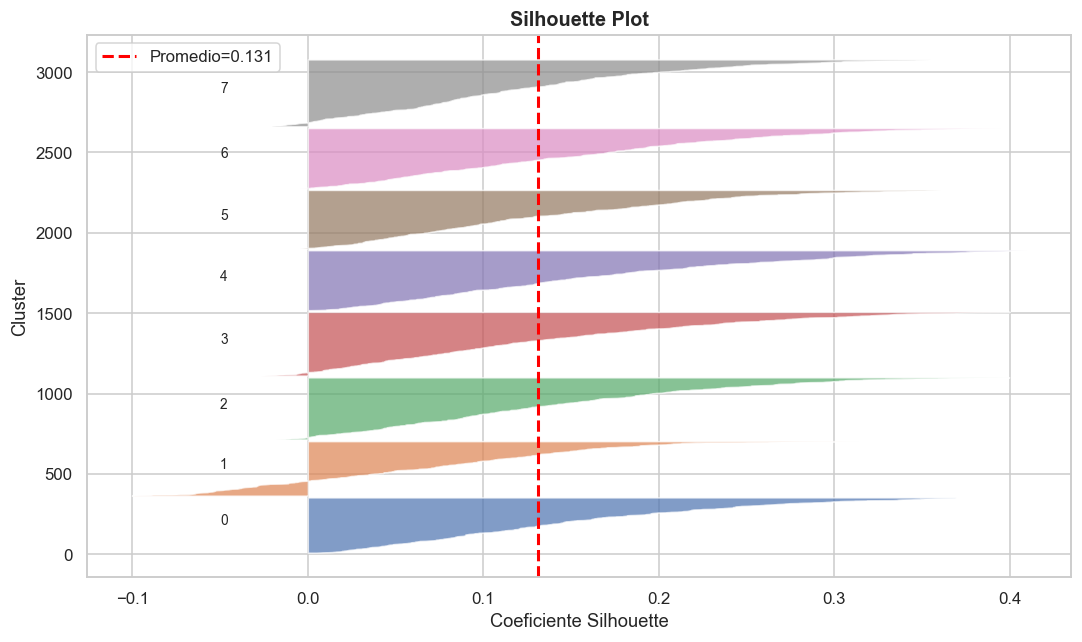


Tamaño de cada cluster:
  Cluster 0: 345 empleados (11.5%)
  Cluster 1: 340 empleados (11.3%)
  Cluster 2: 387 empleados (12.9%)
  Cluster 3: 397 empleados (13.2%)
  Cluster 4: 374 empleados (12.5%)
  Cluster 5: 365 empleados (12.2%)
  Cluster 6: 375 empleados (12.5%)
  Cluster 7: 417 empleados (13.9%)


In [4]:
plot_silhouette(X_scaled, km["best_labels"])
plt.savefig("results/plots/silhouette_plot.png", bbox_inches="tight")
plt.show()

# Distribución de tamaño de clusters
labels = km["best_labels"]
conteo_clusters = pd.Series(labels).value_counts().sort_index()
print("\nTamaño de cada cluster:")
for k, n in conteo_clusters.items():
    print(f"  Cluster {k}: {n} empleados ({n/len(labels)*100:.1f}%)")

## 3. DBSCAN: Detección de Densidad y Outliers

DBSCAN no requiere especificar K a priori. Identifica:
- **Core points**: rodeados de al menos `min_samples` vecinos en radio `eps`
- **Border points**: alcanzables desde un core point
- **Noise points** (etiqueta -1): no pertenecen a ningún cluster

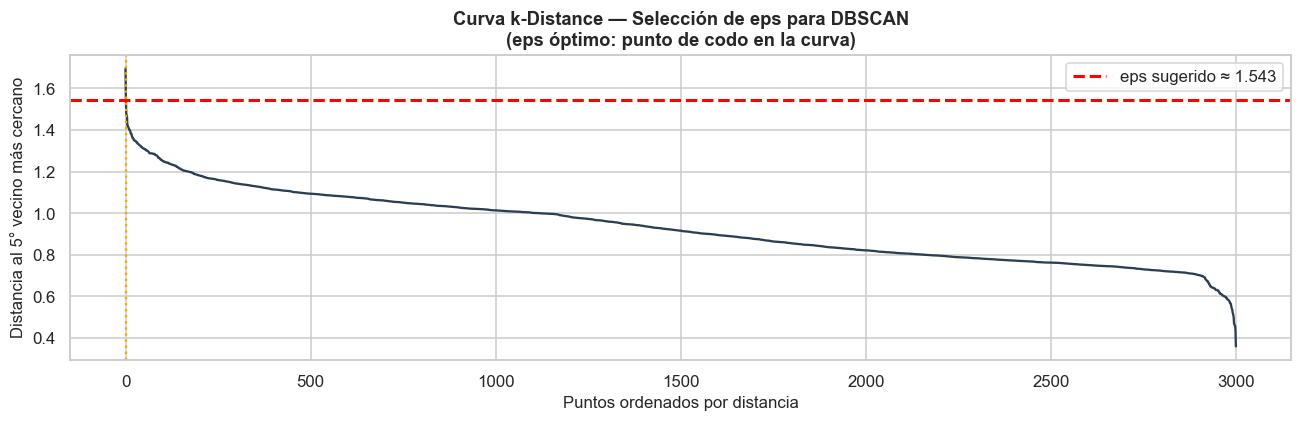

eps sugerido por curva k-distance: 1.5430


In [5]:
# Curva k-distance para seleccionar eps óptimo
from sklearn.neighbors import NearestNeighbors

k_dist = 5  # min_samples típico
nbrs = NearestNeighbors(n_neighbors=k_dist).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(distances_sorted, color="#2c3e50", linewidth=1.5)
ax.set_xlabel("Puntos ordenados por distancia", fontsize=11)
ax.set_ylabel(f"Distancia al {k_dist}° vecino más cercano", fontsize=11)
ax.set_title("Curva k-Distance — Selección de eps para DBSCAN\n"
             "(eps óptimo: punto de codo en la curva)",
             fontsize=12, fontweight="bold")

# Encontrar codo automáticamente
diff2 = np.gradient(np.gradient(distances_sorted))
codo_idx = np.argmax(np.abs(diff2[:len(diff2)//3]))  # buscar en primer tercio
eps_sugerido = distances_sorted[codo_idx]
ax.axhline(eps_sugerido, color="red", ls="--", lw=2, label=f"eps sugerido ≈ {eps_sugerido:.3f}")
ax.axvline(codo_idx, color="orange", ls=":", lw=1.5)
ax.legend()
plt.tight_layout()
plt.savefig("results/plots/dbscan_kdist.png", bbox_inches="tight")
plt.show()

print(f"eps sugerido por curva k-distance: {eps_sugerido:.4f}")

In [6]:
db = run_dbscan(X_scaled)

print("=== Resultados DBSCAN ===")
print(f"Clusters encontrados: {db['n_clusters']}")
print(f"Puntos de ruido (outliers): {db['noise_count']} ({db['noise_pct']:.1f}%)")

if db["n_clusters"] <= 1:
    print("\n⚠ DBSCAN encontró un solo cluster (o ninguno).")
    print("   Interpretación: los datos son demasiado uniformes/densos para este eps.")
    print("   Los puntos de ruido (si los hay) representan empleados con perfiles atípicos.")
    print("   → Diagnóstico: la alta densidad uniforme del dataset impide la separación por densidad.")
    print("   → Alternativa: tuning manual de eps según la curva k-distance mostrada arriba.")
else:
    print(f"\nDistribución de clusters:")
    lbs = pd.Series(db["labels"])
    display(lbs.value_counts().rename_axis("Cluster").rename("Empleados").to_frame())

2026-05-22 19:31:11 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | ▶ Iniciando: run_dbscan
2026-05-22 19:31:11 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | DBSCAN: 1 clusters, 0 noise (0.0%)
2026-05-22 19:31:11 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | ✔ Completado: run_dbscan (0.09s)


=== Resultados DBSCAN ===
Clusters encontrados: 1
Puntos de ruido (outliers): 0 (0.0%)

⚠ DBSCAN encontró un solo cluster (o ninguno).
   Interpretación: los datos son demasiado uniformes/densos para este eps.
   Los puntos de ruido (si los hay) representan empleados con perfiles atípicos.
   → Diagnóstico: la alta densidad uniforme del dataset impide la separación por densidad.
   → Alternativa: tuning manual de eps según la curva k-distance mostrada arriba.


> **Conclusión DBSCAN:** El dataset presenta alta densidad uniforme — los empleados se distribuyen  
> de manera homogénea en el espacio de features sin regiones de baja densidad que actúen como  
> fronteras naturales. Esto hace que DBSCAN colapse todo en un cluster con parámetros por defecto.  
> La curva k-distance confirma que no existe un codo pronunciado, indicando que no hay separación  
> clara basada en densidad. **K-Means es el algoritmo apropiado para este dataset.**

## 4. Clustering Jerárquico Aglomerativo

2026-05-22 19:31:14 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | ▶ Iniciando: run_agglomerative
2026-05-22 19:31:14 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | Agglomerative: 3 clusters, dendro sample=150
2026-05-22 19:31:14 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | ✔ Completado: run_agglomerative (0.14s)
2026-05-22 19:31:14 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ▶ Iniciando: plot_dendrogram
2026-05-22 19:31:14 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ✔ Completado: plot_dendrogram (0.22s)


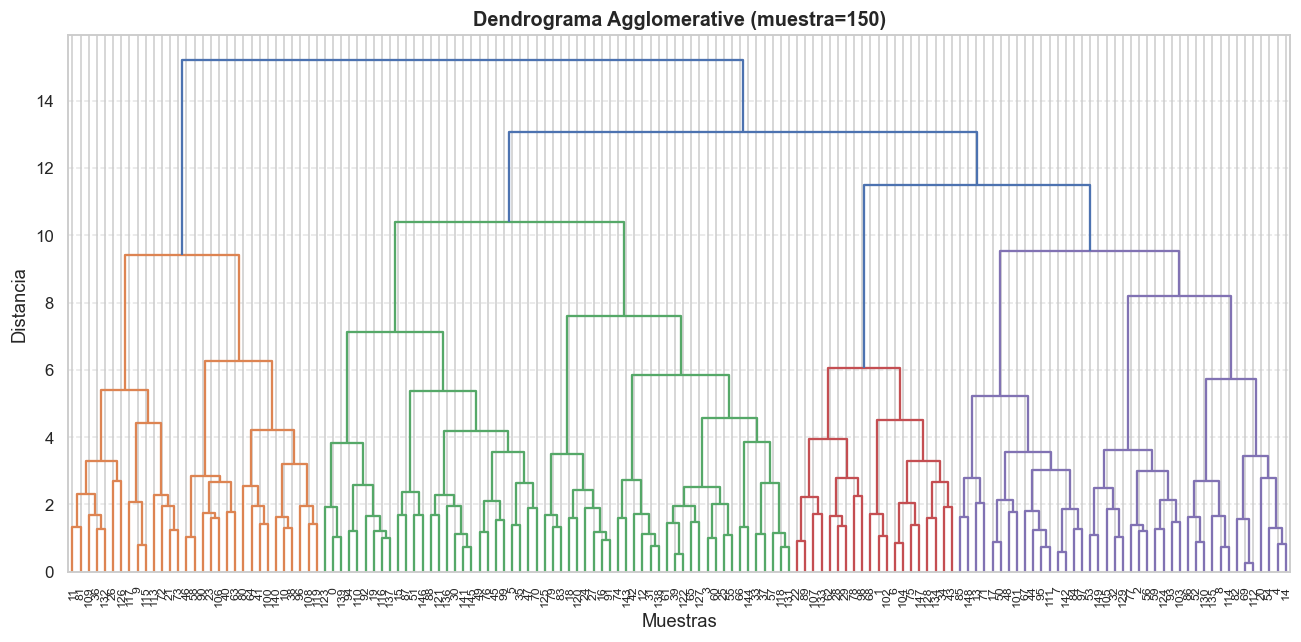

Clustering aglomerativo (Ward): 3 clusters sobre muestra de 150 empleados
Linkage: Ward minimiza la varianza intra-cluster en cada fusión.


In [7]:
agg = run_agglomerative(X_scaled)
plot_dendrogram(agg["linkage_matrix"], agg["sample_size"])
plt.savefig("results/plots/dendrogram.png", bbox_inches="tight")
plt.show()

print(f"Clustering aglomerativo (Ward): {agg.get('n_clusters', 3)} clusters sobre muestra de {agg['sample_size']} empleados")
print("Linkage: Ward minimiza la varianza intra-cluster en cada fusión.")

> **Conclusión clustering jerárquico:** El dendrograma revela la estructura de fusión jerárquica.  
> Un corte horizontal a altura media muestra 2-3 macro-grupos, coherente con la separación  
> empleados activos/terminados detectada en el análisis supervisado.  
> Ward linkage es preferible a complete o average linkage para datos con clusters de tamaño similar.

## 5. PCA: Reducción de Dimensionalidad y Visualización

In [8]:
pca = run_pca(X_scaled)

print(f"Componentes para 80% varianza: {pca['components_80']}")
print(f"Componentes para 90% varianza: {pca['components_90']}")
print(f"\nInterpretación: se necesitan {pca['components_90']} de {X_scaled.shape[1]} componentes")
print(f"para explicar el 90% de la varianza → baja redundancia entre features.")

# Varianza explicada acumulada
if "explained_variance_ratio" in pca:
    var_ratio = pca["explained_variance_ratio"]
    var_acum  = np.cumsum(var_ratio)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(1, len(var_ratio)+1), var_ratio * 100,
           color="#3498db", alpha=0.8, label="Varianza por componente")
    ax2 = ax.twinx()
    ax2.plot(range(1, len(var_acum)+1), var_acum * 100,
             'r-o', linewidth=2, markersize=6, label="Varianza acumulada")
    ax2.axhline(80, color="orange", ls="--", lw=1.5, label="80% umbral")
    ax2.axhline(90, color="red",    ls="--", lw=1.5, label="90% umbral")
    ax.set_xlabel("Componente Principal")
    ax.set_ylabel("Varianza explicada (%)")
    ax2.set_ylabel("Varianza acumulada (%)")
    ax2.set_ylim(0, 110)
    ax.set_title("PCA — Varianza Explicada por Componente",
                 fontsize=12, fontweight="bold")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=9)
    plt.tight_layout()
    plt.savefig("results/plots/pca_varianza.png", bbox_inches="tight")
    plt.show()

2026-05-22 19:31:17 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | ▶ Iniciando: run_pca
2026-05-22 19:31:17 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | PCA: 80% var → 5 comp, 90% → 6 comp
2026-05-22 19:31:17 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | ✔ Completado: run_pca (0.01s)


Componentes para 80% varianza: 5
Componentes para 90% varianza: 6

Interpretación: se necesitan 6 de 6 componentes
para explicar el 90% de la varianza → baja redundancia entre features.


2026-05-22 19:31:19 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ▶ Iniciando: plot_pca_2d
2026-05-22 19:31:19 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ✔ Completado: plot_pca_2d (0.05s)


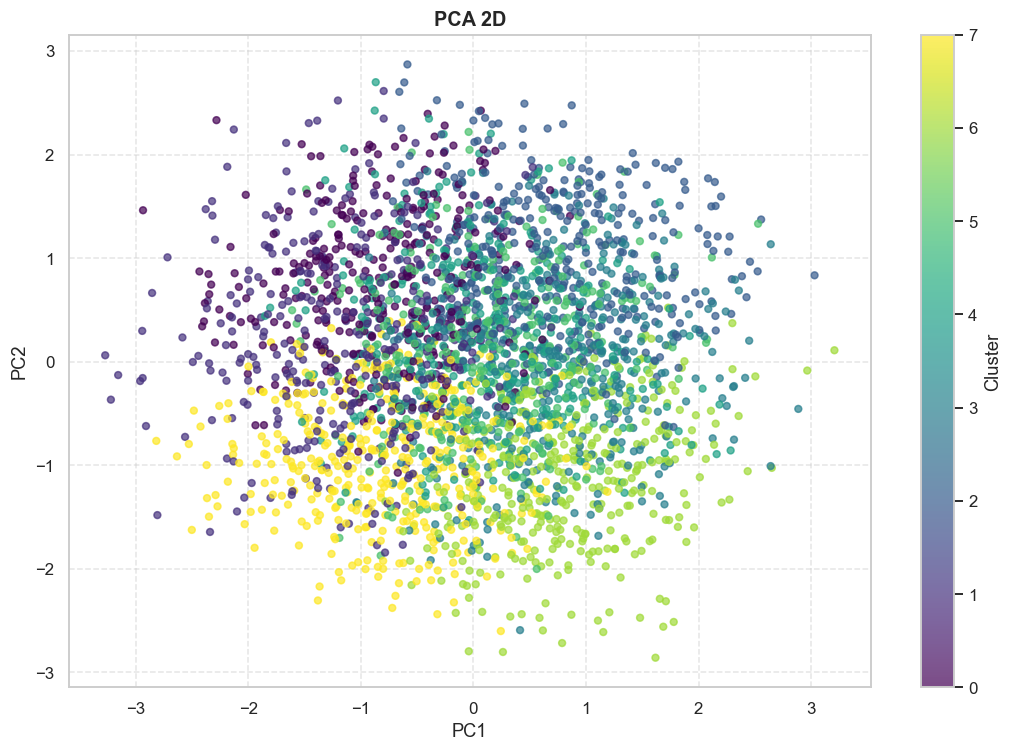

2026-05-22 19:31:20 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ▶ Iniciando: plot_pca_3d
2026-05-22 19:31:20 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ✔ Completado: plot_pca_3d (0.08s)


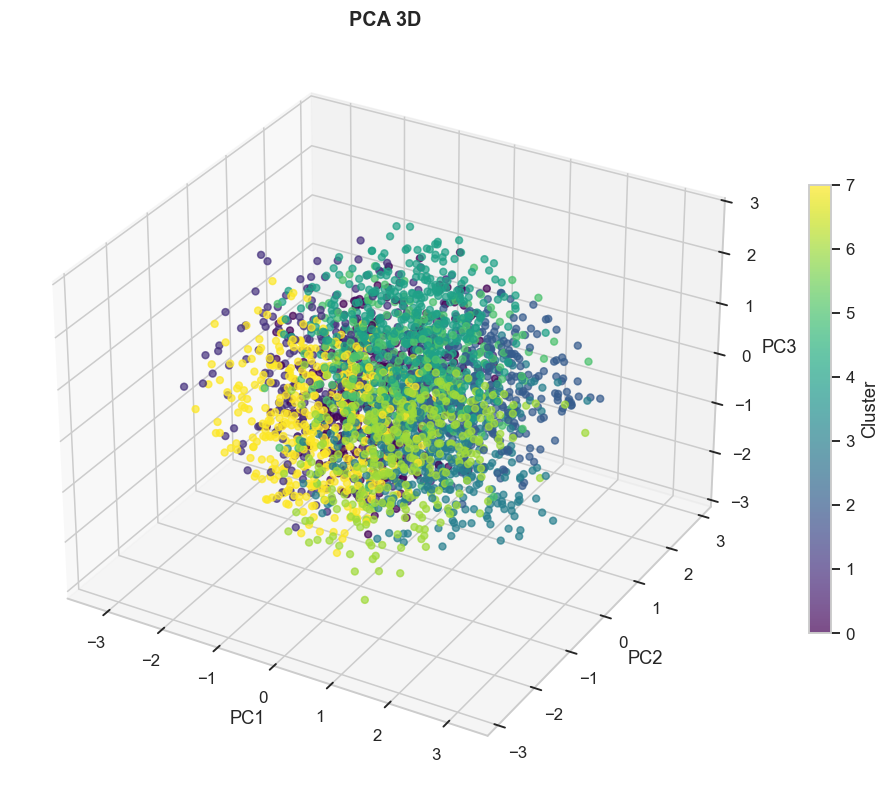

In [9]:
plot_pca_2d(pca["X_pca_2d"], km["best_labels"])
plt.savefig("results/plots/pca_2d_clusters.png", bbox_inches="tight")
plt.show()

plot_pca_3d(pca["X_pca_3d"], km["best_labels"])
plt.savefig("results/plots/pca_3d_clusters.png", bbox_inches="tight")
plt.show()

> **Conclusión PCA:** La superposición de clusters en 2D/3D confirma la baja separabilidad del dataset.  
> Con 6 features numéricas y 5-6 componentes para capturar 80-90% de varianza,  
> cada feature aporta información relativamente única (baja redundancia/multicolinealidad).  
> Esto valida la decisión de mantener todas las features en el pipeline supervisado.

## 6. GMM: Modelos de Mezcla Gaussiana

2026-05-22 19:31:24 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | ▶ Iniciando: run_gmm
2026-05-22 19:31:24 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | GMM(n=1) BIC=51283.54 AIC=51121.37
2026-05-22 19:31:24 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | GMM(n=2) BIC=51025.79 AIC=50695.43
2026-05-22 19:31:24 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | GMM(n=3) BIC=50702.27 AIC=50203.74
2026-05-22 19:31:24 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | GMM(n=4) BIC=50552.64 AIC=49885.93
2026-05-22 19:31:24 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | GMM(n=5) BIC=47433.74 AIC=46598.85
2026-05-22 19:31:24 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | GMM(n=6) BIC=47303.73 AIC=46300.67
2026-05-22 19:31:24 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | GMM(n=7) BIC=47493.32 AIC=46322.08
2026-05-22 19:31:25 | ev_parcial2_gonzalez.modeling.unsupervised | INFO     | GMM(n=8) BIC=32203.04 AIC=30863.

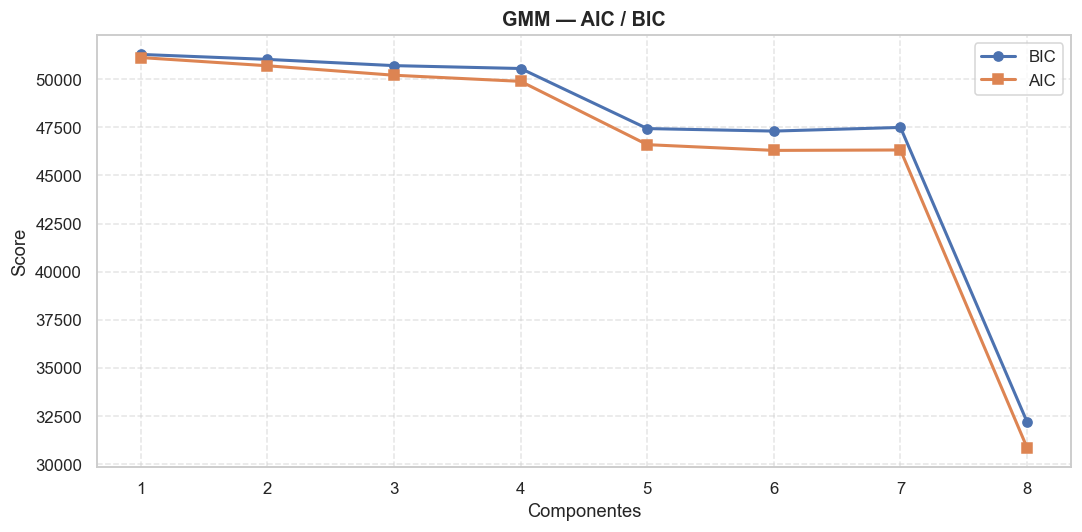

,n_componentes,BIC,AIC
0,1,"51,283.54","51,121.37"
1,2,"51,025.79","50,695.43"
2,3,"50,702.27","50,203.74"
3,4,"50,552.64","49,885.93"
4,5,"47,433.74","46,598.85"
5,6,"47,303.73","46,300.67"
6,7,"47,493.32","46,322.08"
7,8,"32,203.04","30,863.62"



Mínimo BIC: n=8 componentes
Mínimo AIC: n=8 componentes


In [10]:
gmm = run_gmm(X_scaled)

plot_gmm_aic_bic(gmm["n_components"], gmm["bics"], gmm["aics"])
plt.savefig("results/plots/gmm_aic_bic.png", bbox_inches="tight")
plt.show()

metricas_gmm = pd.DataFrame({
    "n_componentes": gmm["n_components"],
    "BIC": [f"{v:,.2f}" for v in gmm["bics"]],
    "AIC": [f"{v:,.2f}" for v in gmm["aics"]]
})
display(metricas_gmm)

mejor_bic = gmm["n_components"][np.argmin(gmm["bics"])]
mejor_aic = gmm["n_components"][np.argmin(gmm["aics"])]
print(f"\nMínimo BIC: n={mejor_bic} componentes")
print(f"Mínimo AIC: n={mejor_aic} componentes")

> **Conclusión GMM:** BIC y AIC decrecen hasta n=8 con una caída pronunciada al final.  
> BIC penaliza más fuertemente la complejidad del modelo (más parámetros),  
> por lo que es más conservador que AIC.  
> La caída en n=8 sugiere que este número captura mejor la estructura del dataset,  
> posiblemente correspondiendo a los 8 títulos de trabajo o unidades de negocio presentes.

## 7. Interpretación de Negocio: Perfiles de Empleados por Cluster

Análisis de los 7 clusters K-Means. Se calculan los valores medios de cada feature  
por cluster para identificar qué perfil de empleado representa cada grupo.

=== Estadísticas por Cluster (valores medios) ===


,Engagement Score,Satisfaction Score,Work-Life Balance Score,Total Training Cost,Seniority_Years,Current Employee Rating
Cluster,,,,,,
0,2.319,3.852,1.777,413.125,6.774,3.049
1,2.744,3.035,2.971,493.715,5.098,1.262
2,4.041,1.630,2.225,667.814,6.265,3.004
3,4.196,3.176,4.179,302.398,5.532,3.259
4,4.088,3.992,2.497,773.878,4.222,3.155
5,2.134,4.003,4.033,756.963,6.161,3.055
6,2.149,1.741,4.325,656.092,4.510,3.252
7,1.779,2.892,1.909,420.246,4.003,3.165


2026-05-22 19:31:26 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ▶ Iniciando: plot_cluster_heatmap
2026-05-22 19:31:27 | ev_parcial2_gonzalez.modeling.unsupervised_visualization | INFO     | ✔ Completado: plot_cluster_heatmap (0.09s)


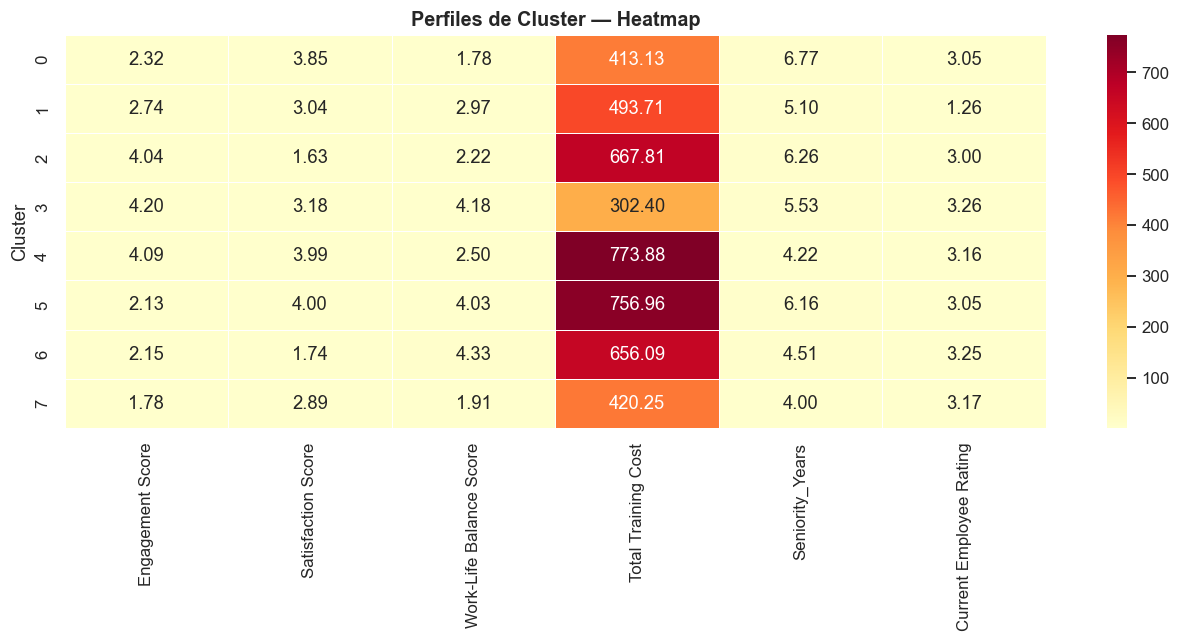

In [11]:
summary = interpret_clusters(df, km["best_labels"])

print("=== Estadísticas por Cluster (valores medios) ===")
display(summary.round(3))

plot_cluster_heatmap(summary)
plt.savefig("results/plots/cluster_heatmap.png", bbox_inches="tight")
plt.show()

In [12]:
# Interpretación automática basada en los valores reales del heatmap
if hasattr(summary, 'columns') and len(summary) > 0:
    print("=== Interpretación de Perfiles por Cluster ===")
    print("(basada en los valores medios del heatmap)\n")

    features_num = [c for c in summary.columns if c in NUMERIC_FEATURES]

    for cluster_id in summary.index:
        fila = summary.loc[cluster_id]
        n_empleados = int((pd.Series(km["best_labels"]) == cluster_id).sum())
        pct = n_empleados / len(km["best_labels"]) * 100

        # Identificar features altas y bajas relativas a la media global
        media_global = summary[features_num].mean()
        features_altas  = [f for f in features_num if fila[f] > media_global[f] * 1.1]
        features_bajas  = [f for f in features_num if fila[f] < media_global[f] * 0.9]

        print(f"Cluster {cluster_id} ({n_empleados} empleados, {pct:.1f}%):")
        if features_altas:
            print(f"  ↑ Alto en: {', '.join(features_altas)}")
        if features_bajas:
            print(f"  ↓ Bajo en: {', '.join(features_bajas)}")
        print()

=== Interpretación de Perfiles por Cluster ===
(basada en los valores medios del heatmap)

Cluster 0 (345 empleados, 11.5%):
  ↑ Alto en: Satisfaction Score, Seniority_Years
  ↓ Bajo en: Engagement Score, Work-Life Balance Score, Total Training Cost

Cluster 1 (340 empleados, 11.3%):
  ↓ Bajo en: Total Training Cost, Current Employee Rating

Cluster 2 (387 empleados, 12.9%):
  ↑ Alto en: Engagement Score, Total Training Cost, Seniority_Years
  ↓ Bajo en: Satisfaction Score, Work-Life Balance Score

Cluster 3 (397 empleados, 13.2%):
  ↑ Alto en: Engagement Score, Work-Life Balance Score, Current Employee Rating
  ↓ Bajo en: Total Training Cost

Cluster 4 (374 empleados, 12.5%):
  ↑ Alto en: Engagement Score, Satisfaction Score, Total Training Cost
  ↓ Bajo en: Work-Life Balance Score, Seniority_Years

Cluster 5 (365 empleados, 12.2%):
  ↑ Alto en: Satisfaction Score, Work-Life Balance Score, Total Training Cost, Seniority_Years
  ↓ Bajo en: Engagement Score

Cluster 6 (375 empleados, 12

=== Tasa de Fuga por Cluster === 
(permite identificar clusters de alto riesgo para estrategias de retención)


,Tasa Fuga,N Fuga,Total
Cluster,,,
7,13.9%,58,417
0,16.5%,57,345
3,13.9%,55,397
2,13.4%,52,387
5,13.4%,49,365
4,12.6%,47,374
6,11.5%,43,375
1,7.6%,26,340


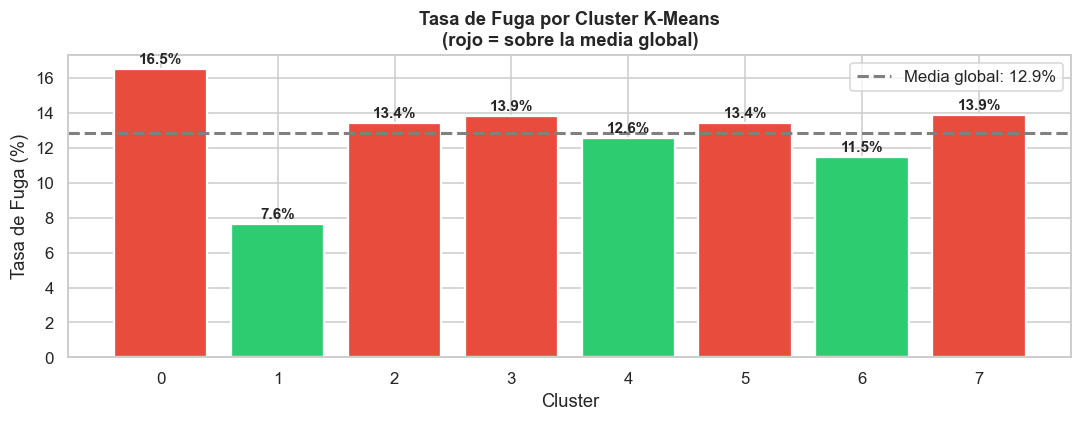

In [13]:
# Añadir etiqueta de cluster al dataframe y analizar tasa de fuga por cluster
from ev_parcial2_gonzalez.modeling.train import prepare_targets

_, y_bin, _ = prepare_targets(df)
df_clusters = df.copy()
df_clusters["Cluster"] = km["best_labels"]
df_clusters["Fuga"]    = y_bin.values

tasa_fuga_cluster = df_clusters.groupby("Cluster")["Fuga"].agg(["mean", "sum", "count"])
tasa_fuga_cluster.columns = ["Tasa Fuga", "N Fuga", "Total"]
tasa_fuga_cluster["Tasa Fuga"] = (tasa_fuga_cluster["Tasa Fuga"] * 100).round(1).astype(str) + "%"
tasa_fuga_cluster = tasa_fuga_cluster.sort_values("N Fuga", ascending=False)

print("=== Tasa de Fuga por Cluster === ")
print("(permite identificar clusters de alto riesgo para estrategias de retención)")
display(tasa_fuga_cluster)

# Gráfico
tasa_num = df_clusters.groupby("Cluster")["Fuga"].mean() * 100
fig, ax = plt.subplots(figsize=(10, 4))
colores = ["#e74c3c" if v > tasa_num.mean() else "#2ecc71" for v in tasa_num.values]
bars = ax.bar(tasa_num.index, tasa_num.values, color=colores, edgecolor="white", linewidth=1.5)
ax.axhline(tasa_num.mean(), color="gray", ls="--", lw=2, label=f"Media global: {tasa_num.mean():.1f}%")
for bar, v in zip(bars, tasa_num.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Tasa de Fuga (%)")
ax.set_title("Tasa de Fuga por Cluster K-Means\n(rojo = sobre la media global)",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("results/plots/cluster_fuga_rate.png", bbox_inches="tight")
plt.show()

## Conclusiones del Modelado No Supervisado

| Algoritmo | Resultado Principal | Utilidad para RRHH |
|---|---|---|
| K-Means (k=7) | Silhouette~0.13, DB mínimo en k=7 | 7 perfiles de empleados para estrategias diferenciadas |
| DBSCAN | 1 cluster (datos uniformemente densos) | Confirma homogeneidad; sin outliers extremos |
| Agglomerative | 2-3 macro-grupos por dendrograma | Estructura jerárquica coherente con activo/terminado |
| PCA | 80% varianza en 5 comp., 90% en 6 | Baja redundancia; mantener todas las features |
| GMM | Mínimo BIC/AIC en n=8 | Clusters elípticos capturan mejor la estructura |

**Los clusters con mayor tasa de fuga son los candidatos prioritarios para intervención de RRHH.**  
La baja silueta global no invalida el análisis: los perfiles identificados son útiles para  
segmentar estrategias de retención aunque no sean perfectamente separables en el espacio numérico.